<a href="https://colab.research.google.com/github/2CarlosM8/Terminal_Economia/blob/main/Proyecto_EconomiaIII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de la rentabilidad de estrategias de trading algorítmico con criptomonedas.

In [ ]:
#!pip install pandas
#!pip install alpha_vantage

In [18]:
import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt

from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import yfinance as BTC
import seaborn as sns

In [ ]:
df_btc = BTC.download('BTC-USD', start='2014-09-17', end='2025-01-01')
df_btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [ ]:
print('Total number of days present in the dataset: ',df_btc.shape[0])
print('Total number of fields present in the dataset: ',df_btc.shape[1])
df_btc.shape

Total number of days present in the dataset:  3759
Total number of fields present in the dataset:  5


(3759, 5)

In [ ]:
print('Null Values:',df_btc.isnull().values.sum())
print('NA values:',df_btc.isnull().values.any())

Null Values: 0
NA values: False


In [ ]:
df_btc.index = pd.to_datetime(df_btc.index)
df_btc['Volume'] = df_btc['Volume'].astype(float)

df_btc.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800.0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200.0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700.0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600.0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100.0


In [ ]:
df_btc.dtypes

,,0
Price,Ticker,
Close,BTC-USD,float64
High,BTC-USD,float64
Low,BTC-USD,float64
Open,BTC-USD,float64
Volume,BTC-USD,float64


In [ ]:
df_btc.columns = ['Cierre', 'Alto', 'Bajo', 'Apertura', 'Volumen']
df_btc.head()

,Cierre,Alto,Bajo,Apertura,Volumen
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800.0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200.0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700.0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600.0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100.0


In [ ]:
df_btc['Tendencia'] = "Estable"
df_btc

,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia
Date,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,2.105680e+07,Estable
2014-09-18,424.440002,456.859985,413.104004,456.859985,3.448320e+07,Estable
2014-09-19,394.795990,427.834991,384.532013,424.102997,3.791970e+07,Estable
2014-09-20,408.903992,423.295990,389.882996,394.673004,3.686360e+07,Estable
2014-09-21,398.821014,412.425995,393.181000,408.084991,2.658010e+07,Estable
...,...,...,...,...,...,...
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,5.241993e+10,Estable
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,2.410744e+10,Estable
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,2.963589e+10,Estable


In [ ]:
df_btc['Diferencia'] = df_btc['Apertura'] - df_btc['Cierre']
df_btc

,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia
Date,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,2.105680e+07,Estable,8.529999
2014-09-18,424.440002,456.859985,413.104004,456.859985,3.448320e+07,Estable,32.419983
2014-09-19,394.795990,427.834991,384.532013,424.102997,3.791970e+07,Estable,29.307007
2014-09-20,408.903992,423.295990,389.882996,394.673004,3.686360e+07,Estable,-14.230988
2014-09-21,398.821014,412.425995,393.181000,408.084991,2.658010e+07,Estable,9.263977
...,...,...,...,...,...,...,...
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,5.241993e+10,Estable,1540.117188
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,2.410744e+10,Estable,-1003.742188
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,2.963589e+10,Estable,1643.828125


In [ ]:
df_btc.loc[df_btc['Diferencia'] > 0, 'Tendencia'] = 'Subida'
df_btc.loc[df_btc['Diferencia'] < 0, 'Tendencia'] = 'Bajada'
df_btc

,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia
Date,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,2.105680e+07,Subida,8.529999
2014-09-18,424.440002,456.859985,413.104004,456.859985,3.448320e+07,Subida,32.419983
2014-09-19,394.795990,427.834991,384.532013,424.102997,3.791970e+07,Subida,29.307007
2014-09-20,408.903992,423.295990,389.882996,394.673004,3.686360e+07,Bajada,-14.230988
2014-09-21,398.821014,412.425995,393.181000,408.084991,2.658010e+07,Subida,9.263977
...,...,...,...,...,...,...,...
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,5.241993e+10,Subida,1540.117188
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,2.410744e+10,Bajada,-1003.742188
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,2.963589e+10,Subida,1643.828125


In [ ]:
df_btc.to_csv('BTC_USD.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_btc.to_excel('/content/drive/MyDrive/Colab Notebooks/BTC_USD.xlsx')

In [ ]:
df_btc = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/BTC_USD.xlsx')
df_btc.head()

,Date,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977


In [ ]:
df_btc.head()

,Date,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977


In [ ]:
df_btc.tail()

,Date,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia
3754,2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565,Subida,1540.117188
3755,2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,Bajada,-1003.742188
3756,2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,Subida,1643.828125
3757,2024-12-30,92643.210938,94903.320312,91317.132812,93527.195312,56188003691,Subida,883.984375
3758,2024-12-31,93429.203125,96090.601562,91914.031250,92643.250000,43625106843,Bajada,-785.953125


In [ ]:
df_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3759 entries, 0 to 3758
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        3759 non-null   datetime64[ns]
 1   Cierre      3759 non-null   float64       
 2   Alto        3759 non-null   float64       
 3   Bajo        3759 non-null   float64       
 4   Apertura    3759 non-null   float64       
 5   Volumen     3759 non-null   int64         
 6   Tendencia   3759 non-null   object        
 7   Diferencia  3759 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 235.1+ KB


In [ ]:
#df_btc['Año'] = df_btc.index.year
#df_btc['Mes'] = df_btc.index.month
#df_btc['Día'] = df_btc.index.day
#df_btc['Día de la Semana'] = df_btc.index.dayofweek
#df_btc

In [ ]:
# Convert the 'Date' column to DatetimeIndex and set it as the index
df_btc['Date'] = pd.to_datetime(df_btc['Date'])  # Assuming 'Date' is the column name
df_btc = df_btc.set_index('Date')

# Now you can extract year, month, and day
df_btc['Año'] = df_btc.index.year
df_btc['Mes'] = df_btc.index.month
df_btc['Día'] = df_btc.index.day
df_btc['Día de la Semana'] = df_btc.index.dayofweek
df_btc

,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia,Año,Mes,Día,Día de la Semana
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999,2014,9,17,2
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983,2014,9,18,3
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007,2014,9,19,4
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988,2014,9,20,5
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977,2014,9,21,6
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565,Subida,1540.117188,2024,12,27,4
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,Bajada,-1003.742188,2024,12,28,5
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,Subida,1643.828125,2024,12,29,6


In [ ]:
df_btc = df_btc.reset_index()
df_btc

,Date,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia,Año,Mes,Día,Día de la Semana
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999,2014,9,17,2
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983,2014,9,18,3
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007,2014,9,19,4
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988,2014,9,20,5
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977,2014,9,21,6
...,...,...,...,...,...,...,...,...,...,...,...,...
3754,2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565,Subida,1540.117188,2024,12,27,4
3755,2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,Bajada,-1003.742188,2024,12,28,5
3756,2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,Subida,1643.828125,2024,12,29,6
3757,2024-12-30,92643.210938,94903.320312,91317.132812,93527.195312,56188003691,Subida,883.984375,2024,12,30,0


In [ ]:
df_btc.rename(columns = {'Date': 'Fecha'}, inplace = True)
df_btc

,Fecha,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia,Año,Mes,Día,Día de la Semana
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999,2014,9,17,2
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983,2014,9,18,3
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007,2014,9,19,4
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988,2014,9,20,5
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977,2014,9,21,6
...,...,...,...,...,...,...,...,...,...,...,...,...
3754,2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565,Subida,1540.117188,2024,12,27,4
3755,2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185,Bajada,-1003.742188,2024,12,28,5
3756,2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267,Subida,1643.828125,2024,12,29,6
3757,2024-12-30,92643.210938,94903.320312,91317.132812,93527.195312,56188003691,Subida,883.984375,2024,12,30,0


In [ ]:
df_btc.to_excel('/content/drive/MyDrive/Colab Notebooks/BTC_USD.xlsx')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df_btc = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/BTC_USD.xlsx')
df_btc.head()

,Unnamed: 0,Fecha,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia,Año,Mes,Día,Día de la Semana
0,0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999,2014,9,17,2
1,1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983,2014,9,18,3
2,2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007,2014,9,19,4
3,3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988,2014,9,20,5
4,4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977,2014,9,21,6


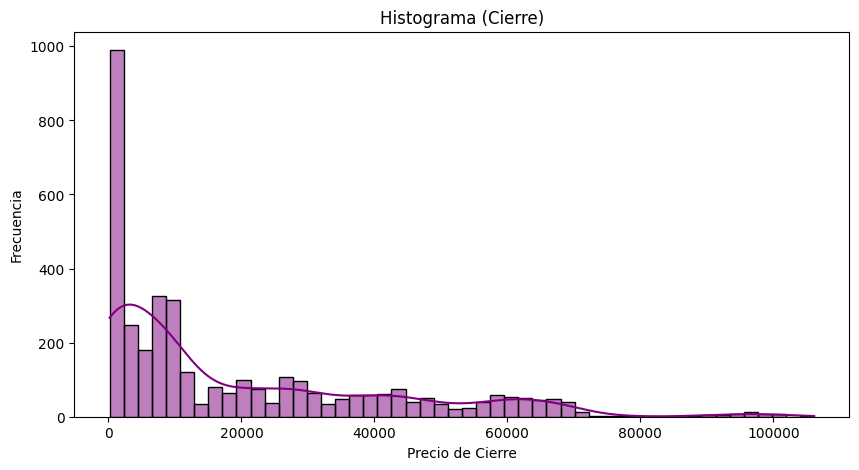

In [7]:
plt.figure(figsize = (10,5))
sns.histplot(df_btc['Cierre'], bins = 50, kde = True, color = 'purple')
plt.title('Histograma (Cierre)')
plt.xlabel('Precio de Cierre')
plt.ylabel('Frecuencia')
plt.show()

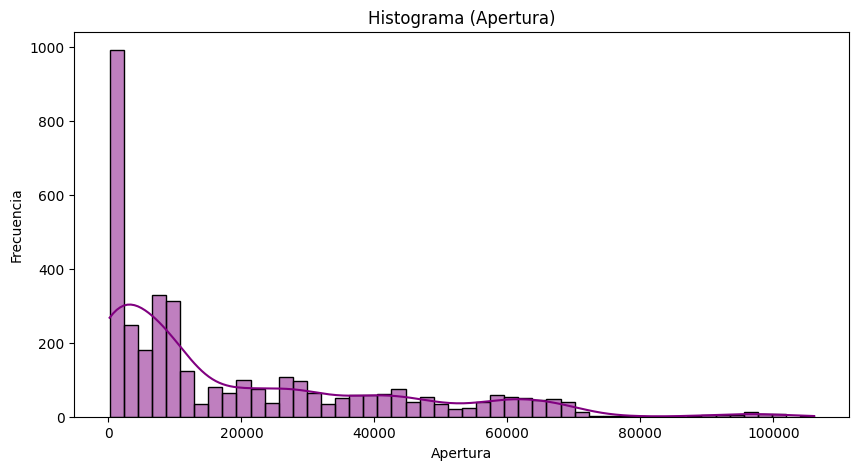

In [8]:
plt.figure(figsize = (10,5))
sns.histplot(df_btc['Apertura'], bins = 50, kde = True, color = 'purple')
plt.title('Histograma (Apertura)')
plt.xlabel('Apertura')
plt.ylabel('Frecuencia')
plt.show()

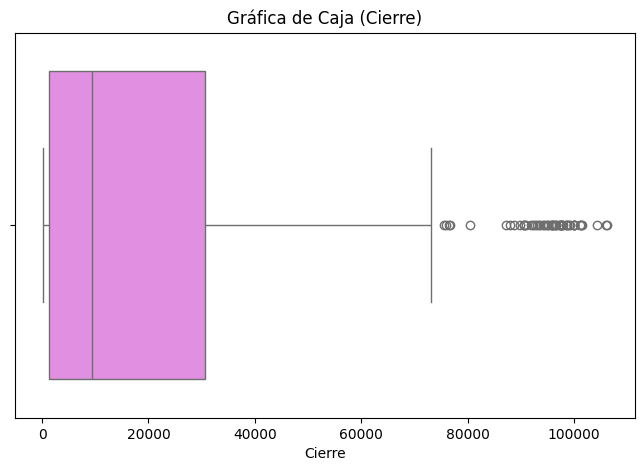

In [9]:
plt.figure(figsize = (8,5))
sns.boxplot(x = df_btc['Cierre'], color = 'violet')
plt.title('Gráfica de Caja (Cierre)')
plt.show()

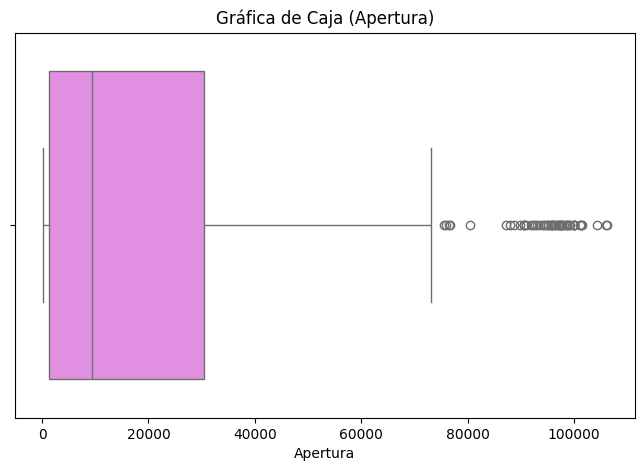

In [10]:
plt.figure(figsize = (8,5))
sns.boxplot(x = df_btc['Apertura'], color = 'violet')
plt.title('Gráfica de Caja (Apertura)')
plt.show()

In [12]:
Q1 = df_btc['Cierre'].quantile(0.25)
Q3 = df_btc['Cierre'].quantile(0.75)
IQR = Q3 - Q1

In [13]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [14]:
df_filtro = df_btc[(df_btc['Cierre'] <= limite_inferior) | (df_btc['Cierre'] >= limite_superior)]
df_filtro.head()

,Unnamed: 0,Fecha,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia,Año,Mes,Día,Día de la Semana
3703,3703,2024-11-06,75639.078125,76460.156250,69322.031250,69358.500000,118592653963,Bajada,-6280.578125,2024,11,6,2
3704,3704,2024-11-07,75904.859375,76943.117188,74480.421875,75637.085938,63467654989,Bajada,-267.773438,2024,11,7,3
3705,3705,2024-11-08,76545.476562,77252.750000,75648.742188,75902.835938,55176858003,Bajada,-642.640625,2024,11,8,4
3706,3706,2024-11-09,76778.867188,76932.765625,75773.789062,76556.187500,29009480361,Bajada,-222.679688,2024,11,9,5
3707,3707,2024-11-10,80474.187500,81474.421875,76565.429688,76775.546875,82570594495,Bajada,-3698.640625,2024,11,10,6


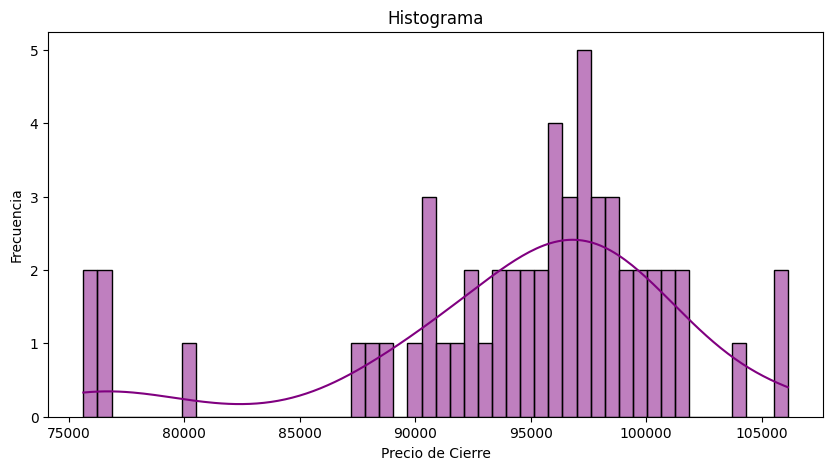

In [15]:
plt.figure(figsize = (10,5))
sns.histplot(df_filtro['Cierre'], bins = 50, kde = True, color = 'purple')
plt.title('Histograma')
plt.xlabel('Precio de Cierre')
plt.ylabel('Frecuencia')
plt.show()

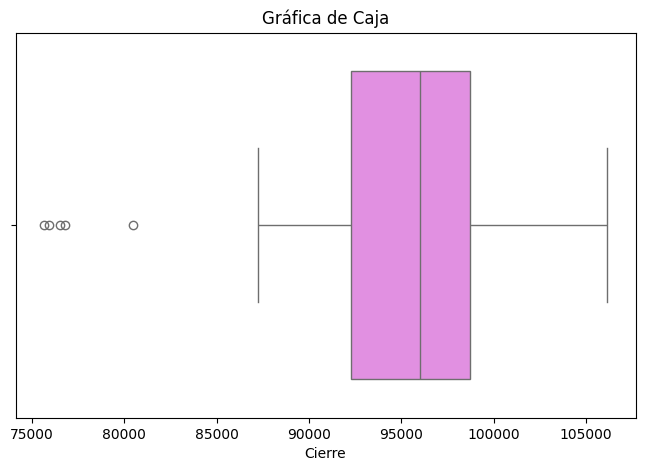

In [16]:
plt.figure(figsize = (8,5))
sns.boxplot(x = df_filtro['Cierre'], color = 'violet')
plt.title('Gráfica de Caja')
plt.show()

In [25]:
corr_matrix = df_btc[['Cierre','Apertura','Bajo','Alto','Volumen']].corr()
corr_matrix

,Cierre,Apertura,Bajo,Alto,Volumen
Cierre,1.000000,0.999091,0.999524,0.999619,0.670113
Apertura,0.999091,1.000000,0.999371,0.999579,0.670731
Bajo,0.999524,0.999371,1.000000,0.999237,0.661322
Alto,0.999619,0.999579,0.999237,1.000000,0.676667
Volumen,0.670113,0.670731,0.661322,0.676667,1.000000


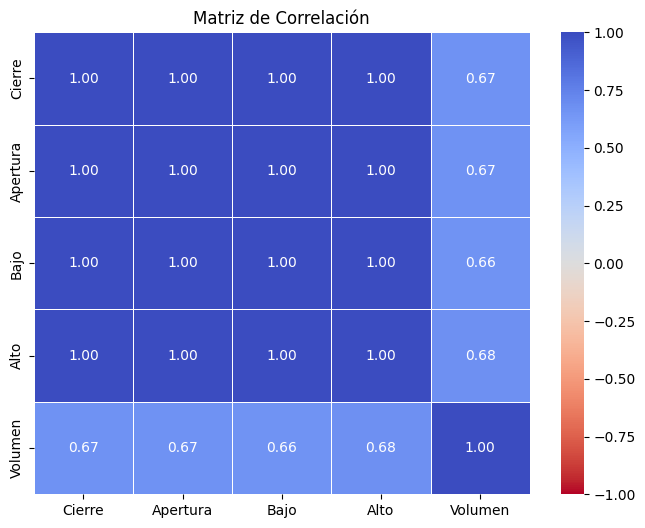

In [26]:
plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix, annot = True, vmin = -1, vmax = 1, cmap = 'coolwarm_r', linewidth = 0.5, fmt = ".2f")
plt.title('Matriz de Correlación')
plt.show()

In [19]:
fig = px.scatter_matrix(df_btc, dimensions = ['Cierre', 'Apertura', 'Bajo', 'Alto', 'Volumen'], color = 'Tendencia', title = 'Correlación', template = 'plotly_white')
fig.show()

In [20]:
df_btc['Volatilidad'] = df_btc.Alto - df_btc.Bajo
df_btc.head()

,Unnamed: 0,Fecha,Cierre,Alto,Bajo,Apertura,Volumen,Tendencia,Diferencia,Año,Mes,Día,Día de la Semana,Volatilidad
0,0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,Subida,8.529999,2014,9,17,2,15.752014
1,1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,Subida,32.419983,2014,9,18,3,43.755981
2,2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,Subida,29.307007,2014,9,19,4,43.302979
3,3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,Bajada,-14.230988,2014,9,20,5,33.412994
4,4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,Subida,9.263977,2014,9,21,6,19.244995


In [21]:
fig = px.line(df_btc, x = df_btc.Fecha, y = df_btc.Volatilidad, title = 'Volatilidad', template = 'plotly_white')
fig.show()

In [22]:
fig = px.scatter(df_btc, x = 'Volumen', y = 'Cierre', title = 'Volumen vs Cierre', template = 'plotly_white')
fig.show()

In [23]:
df_btc.to_excel('/content/drive/MyDrive/Colab Notebooks/BTC_USD.xlsx')